# Cross Era Greatness ETL project 
------

In this `Cross Era Greatness` (CEG) project, I will be comparing the careers and player dominance of the three unanimously agreed upon NBA greats: 
- Lebron James
- Michael Jordan
- Kareem Abdul Jabbar

<u/>*Disclaimer*</u> The names written above are in no particular order of greatness, there will be no bias in the analysis of this project.

In [87]:
#Load important libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [88]:
NBA_avg = pd.read_excel("raw data/NBA averages.xlsx")

In [89]:
#And to import the Franchise index dataset and players dataset, which is a workbook with multiple sheets, we will use the following code: 

logs = pd.read_excel("raw data/NBA Franchise Index.xlsx", sheet_name = None)

LAL = logs["LAL"]
CHI = logs["CHI"]
MIL = logs["MIL"]
WAS = logs["WAS"]
MIA = logs["MIA"]
CLE = logs["CLE"]

players = pd.read_excel("raw data/Players_stats.xlsx", sheet_name = None)

LBJ = players["Lebron"]
MJ = players["MJ"]
KAJ = players["Kareem"]

LAL.head()

,Season,Lg,Team,W,L,W/L%,Finish,SRS,Pace,Rel Pace,ORtg,Rel ORtg,DRtg,Rel DRtg,Playoffs,Coaches,Top WS
0,2025-26,NBA,Los Angeles Lakers*,53,29,0.646,1st of 5,1.68,98.3,-1.1,118.2,2.4,116.4,0.6,Won W. Conf. 1st Rnd.,J. Redick (53-29),L. Dončić (9.5)
1,2024-25,NBA,Los Angeles Lakers*,50,32,0.610,1st of 5,1.45,97.6,-1.2,115.9,1.4,114.7,0.2,Lost W. Conf. 1st Rnd.,J. Redick (50-32),L. James (7.7)
2,2023-24,NBA,Los Angeles Lakers*,47,35,0.573,3rd of 5,1.07,100.9,2.4,115.9,0.6,115.3,0.0,Lost W. Conf. 1st Rnd.,D. Ham (47-35),A. Davis (11.8)
3,2022-23,NBA,Los Angeles Lakers*,43,39,0.524,5th of 5,0.43,101.3,2.2,114.5,-0.3,113.9,-0.9,Lost W. Conf. Finals,D. Ham (43-39),A. Davis (9.0)
4,2021-22,NBA,Los Angeles Lakers,33,49,0.402,4th of 5,-3.08,100.1,1.9,110.3,-1.7,113.3,1.3,NaN,F. Vogel (33-49),L. James (7.5)


Note: In the code above I have used the acronyms which most people are familiar with. 

- LBJ = Lebron James
- MJ = Micheal Jordan
- KAJ = Kareem Abdul Jabbar
- NBA_avg = National Basketball Association averages

### Transformation/Cleaning

In the following few lines of code, I will `clean up and transform the datasets`, and later I will also standardize values to match the scales in order to produce academically correct plots.

Since I am only interested in the statistics for each year, and not statistics on a particular team, I will omit all rows which show information past individual year statistics.

In [90]:
#Since I am only interested in the statistics for each year, and not statistics on a particular team, I will omit all rows which show information past individual year statistics.
KAJ = KAJ[0:20]
LBJ = LBJ[0:23]
MJ = MJ[0:19]


In [91]:
#For all entries where the player did not play, replace the value with 0
#MJ = MJ.replace(["Did not play - retired/MiLB", "Did not play - retired"], 0)

#Or we could simply drop the rows where the player did not play, since they do not contribute to the analysis of the players' careers.
MJ = MJ[~MJ["G"].isin(["Did not play - retired/MiLB", "Did not play - retired"])] #~ is used to negate the condition, so here we are basically saying we want all rows except where player did not play.
MJ

,Season,Age,Team,Lg,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,1984-85,21,CHI,NBA,SG,82,82,38.3,10.2,19.8,...,2,4.5,6.5,5.9,2.4,0.8,3.5,3.5,28.2,MVP-6ROY-1ASNBA2
1,1985-86,22,CHI,NBA,SG,18,7,25.1,8.3,18.2,...,1.3,2.3,3.6,2.9,2.1,1.2,2.5,2.6,22.7,AS
2,1986-87,23,CHI,NBA,SG,82,82,40,13.4,27.8,...,2,3.2,5.2,4.6,2.9,1.5,3.3,2.9,37.1,MVP-2DPOY-8ASNBA1
3,1987-88,24,CHI,NBA,SG,82,82,40.4,13,24.4,...,1.7,3.8,5.5,5.9,3.2,1.6,3.1,3.3,35,MVP-1DPOY-1ASNBA1DEF1
4,1988-89,25,CHI,NBA,SG,81,81,40.2,11.9,22.2,...,1.8,6.2,8,8,2.9,0.8,3.6,3,32.5,MVP-2DPOY-5ASNBA1DEF1
5,1989-90,26,CHI,NBA,SG,82,82,39,12.6,24,...,1.7,5.1,6.9,6.3,2.8,0.7,3,2.9,33.6,MVP-3DPOY-5ASNBA1DEF1
6,1990-91,27,CHI,NBA,SG,82,82,37,12.1,22.4,...,1.4,4.6,6,5.5,2.7,1,2.5,2.8,31.5,MVP-1DPOY-7ASNBA1DEF1
7,1991-92,28,CHI,NBA,SG,80,80,38.8,11.8,22.7,...,1.1,5.3,6.4,6.1,2.3,0.9,2.5,2.5,30.1,MVP-1DPOY-3ASNBA1DEF1
8,1992-93,29,CHI,NBA,SG,78,78,39.3,12.7,25.7,...,1.7,5,6.7,5.5,2.8,0.8,2.7,2.4,32.6,MVP-3DPOY-2ASNBA1DEF1
10,1994-95,31,CHI,NBA,SG,17,17,39.3,9.8,23.8,...,1.5,5.4,6.9,5.3,1.8,0.8,2.1,2.8,26.9,MVP-11


In [92]:
#Let us also convert all the statistical categories to a numeric value to that we plot them without trouble.

players = [KAJ, LBJ, MJ]

cols_to_float = ["PTS", "TRB", "AST", "STL", "BLK", "TOV", "PF", "DRB", "ORB", "FG", "FT", "MP", "FGA", "FTA"]
cols_to_int = ["Age", "G"]
cols_to_string = ["Season", "Team", "Lg", "Pos"]

for df in players:
    df[cols_to_float] = df[cols_to_float].astype(float)
    df[cols_to_int] = df[cols_to_int].astype(int)
    df[cols_to_string] = df[cols_to_string].astype(str)


NBA_avg[cols_to_float] = NBA_avg[cols_to_float].astype(float)

team_list = [LAL, CHI, MIL, WAS, MIA, CLE]
for team in team_list:
    team[cols_to_string[0]] = team[cols_to_string[0]].astype(str)

In [93]:
#Assuming Kareem Abdul Jabbar was an integral part of every team he played for we will assume that he started for all of the games he played, 
#so we will impute the same number for games started (GS) as games played (GP).
#This is a reasonable assumption since Kareem Abdul Jabbar was a dominant player in his era and was known for his consistency and durability, so it is likely that he started in most of the games he played.
 
KAJ["GS"] = KAJ["G"]

In [94]:
#We will omit all rows before Kareem Abdul Jabbar's rookie season (started career before both Lebron James and Michael Jordan) since we are only interested in comparing the careers of the three players, and not their pre-NBA careers.

NBA_avg["Season"] = NBA_avg["Season"].astype(str) #Convert the season column to string so that we can compare it with the season column in the other dataframes, which is also a string.
NBA_avg = NBA_avg[NBA_avg["Season"] >= "1969-70"]

NBA_avg.tail()

,Rk,Season,Lg,Age,Ht,Wt,G,MP,FG,FGA,...,FG%,3P%,FT%,Pace,eFG%,TOV%,ORB%,FT/FGA,ORtg,TS%
52,53,1973-74,NBA,26.9,2026-06-06,205.0,697,241.0,43.1,93.9,...,0.459,NaN,0.771,107.8,0.459,16.5,30.5,0.209,97.7,0.503
53,54,1972-73,NBA,26.7,2026-06-06,205.0,697,240.9,44.2,96.9,...,0.456,NaN,0.758,NaN,0.456,15.7,NaN,0.198,NaN,0.498
54,55,1971-72,NBA,26.6,2026-06-06,206.0,697,241.1,43.4,95.5,...,0.455,NaN,0.748,NaN,0.455,15.2,NaN,0.244,NaN,0.504
55,56,1970-71,NBA,26.6,2026-06-06,205.0,697,241.0,44.0,98.0,...,0.449,NaN,0.745,NaN,0.449,14.8,NaN,0.248,NaN,0.500
56,57,1969-70,NBA,26.8,2026-06-06,205.0,574,241.6,45.7,99.4,...,0.460,NaN,0.751,NaN,0.460,1.3,NaN,0.255,NaN,0.511


In [95]:
#Create indecies for the seasons since when comparing the statistical categories we would like to observe the progression of the players throughout their careers rather
#than comparing them in time.

KAJ["Season Number"] = range(1, len(KAJ) + 1)
LBJ["Season Number"] = range(1, len(LBJ) + 1)
MJ["Season Number"] = range(1, len(MJ) + 1)

In [96]:
#Notice the difference in time formating for a few of the seasons listed, we will fix this using regular expressions.

#First import re (regular expressions library)

import re

#Now we will correct our formatting for the season column in all dataframes imported.

list_of_dfs = [KAJ, LBJ, MJ, NBA_avg, LAL, CHI, MIL, WAS, MIA, CLE] #List of all dataframes we want to apply the regular expression to. 

pattern = r"(\d{4})-(\d{2})-(\d{2})*" #The pattern we want to match and replace with the new one. 
replace = r"\1-\2" #The pattern we want the matched pattern to be replaced with

for df in list_of_dfs:
    df["Season"] = df["Season"].apply(lambda x: re.sub(pattern, replace, x))
    df["Season"] = df["Season"].astype(str).str.slice(0,7) #This will slice the season column to only keep the first 7 characters, which will give us the format we want (e.g. 1969-70).
    df = df.sort_values("Season") #to sort the seasons in chronological order. This will help with our visualizations and analysis. df


A few assumptions to make:
- On average, each player will contribute evenly to the team. This assumption allows us to generalize the player contribution, and consider the average per player rather than a more sophisticated comparison.
- All data retrieved from [Basketball reference](https://www.basketball-reference.com/) is correct and upto date.
- NBA statistics could be predicted using other statistical categories (dependency exists).

### Imputation 
-----
In the following cells I will be using `single regression imputation` to impute the missing values for some of the statistical categories that were not recorded at the time Kareem Abdul Jabbar started his career. 

More specifically I will be using multiple linear regression to regress my predictor onto my covariables. (This will all be done automatically using `IterativeImputer` as shown below)

The multiple linear regression model is:
$$Y = \beta_0 + \beta_1X_1 + \beta_2X_3 + ... + \epsilon$$

**Where:** 

- Y = Response Variable (what we are trying to predict)
- $\beta_i$, $i \in {(1,2,3,...)}$, are the coefficients of predictor variables.
- $X_i$, $i \in {(1,2,3,...)}$, are the predictor variables.
- $\epsilon$ is the error term from our prediction.

Note: When using linear regression, we need to make key assumptions about the distribution of the error terms, i.e. they must be independent and normally distributed with mean 0 and constant variance, but for regression imputation, we do not need to check or make this assumption since simple (what well use) imputation is quite robust and when we are using regression, it is just an approximation to conditional mean (Conditional mean: Statistic which gives us the best prediction for Y given X.)


In [97]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#since I only want numerical variables to be used as predictor variables, I will create list of all numerical variables well use in our imputation model.

predictors = ["G", "GS", "MP", "FG", "FGA", "FG%", "3P", "3PA", "3P%", "2P", "2PA", "2P%", "eFG%", "FT", "FTA", "FT%", "ORB", "DRB", "TRB", "AST", "STL", "BLK", "TOV", "PF", "PTS"]

selector = ColumnTransformer([
    ("select", "passthrough", predictors)
])

piped_imputer = Pipeline(steps = [
    ("selector", selector),
    ("imputer", IterativeImputer(estimator=LinearRegression(), max_iter = 10, random_state = 0))]) #set random_state to 0 for reproducibility (could be any number)

KAJ_imputed = piped_imputer.fit_transform(KAJ)

KAJ_imputed_df = pd.DataFrame(KAJ_imputed, columns = predictors)

KAJ_imputed_df.head()

c:\Users\Moahhid Amir\Passion projects\CEG ETL and visualizations project\.venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,82.0,82.0,43.1,11.4,22.1,0.518,0.0,0.0,3.626693,11.4,...,0.653,6.841250,9.609661,14.5,4.1,5.523041,7.920011,6.981689,3.5,28.8
1,82.0,82.0,40.1,13.0,22.5,0.577,0.0,0.0,4.106838,13.0,...,0.690,8.345144,9.575177,16.0,3.3,5.949465,7.315870,7.196383,3.2,31.7
2,81.0,81.0,44.2,14.3,24.9,0.574,0.0,0.0,4.928495,14.3,...,0.689,8.937816,10.127815,16.6,4.6,6.304426,9.702916,8.783120,2.9,34.8
3,76.0,76.0,42.8,12.9,23.3,0.554,0.0,0.0,4.077679,12.9,...,0.713,8.495020,9.741102,16.1,5.0,6.075393,8.008068,8.357550,2.7,30.2
4,81.0,81.0,43.8,11.7,21.7,0.539,0.0,0.0,-1.361648,11.7,...,0.702,3.500000,11.000000,14.5,4.8,1.400000,3.500000,3.452413,2.9,27.0


In [98]:
#Now we will replace the original columns in the KAJ dataframe with the imputed values.

#And also fill in all values related to beyond the arc with 0 since Kareem Abdul Jabbar played in an era where the three point line did not exist, and also when it was introduced,
#Kareem Abdul Jabbar was in the twilight of his career and was not known for his three point shooting, so it is reasonable to assume that he did not make any three pointers in his career.

KAJ[predictors] = KAJ_imputed_df[predictors]
KAJ[["3P", "3PA", "3P%"]] = 0

In [99]:
#I will again use single regression imputation to fill in the missing values for the NBA averages dataframe, using the same pipeline as before, but different predictor variables.

predictors2 = ["Age", "G", "MP", "FG", "FGA", "3P", "3PA", "FT", "FTA", "ORB", "DRB", "TRB", "AST", "STL",
                "BLK", "TOV", "PF", "PTS", "FG%", "3P%", "FT%", "Pace", "eFG%", "TOV%", "ORB%", "FT/FGA", "ORtg", "TS%"]

selector2 = ColumnTransformer([("select", "passthrough", predictors2)]) # Select only the predictor columns and pass them through to the imputer.

piped_imputer2 = Pipeline(steps = [("selector2", selector2),
                                   ("imputer2", IterativeImputer(estimator=LinearRegression(), max_iter = 10, random_state = 0))]) #set random state to 0 for reproducibility

NBA_avg_imputed = piped_imputer2.fit_transform(NBA_avg) # Fit the imputation model and return the imputed predictor matrix as a NumPy array.

NBA_avg_imputed_df = pd.DataFrame(NBA_avg_imputed, columns = predictors2)  

NBA_avg[predictors2] = NBA_avg_imputed_df[predictors2]

NBA_avg[["Season", "Pace"]].head()


c:\Users\Moahhid Amir\Passion projects\CEG ETL and visualizations project\.venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,Season,Pace
0,2025-26,99.4
1,2024-25,98.8
2,2023-24,98.5
3,2022-23,99.2
4,2021-22,98.2


# Player Comparison
In order to compare statistics from the careers of Lebron James, Micheal Jordan and Kareem Abdul Jabbar against the average NBA player from each era; I will need to `standardize` the few key metrics to compare. 

These metrics include:
- PTS (points)
- AST (Assists)
- TRB (Total Rebounds)
- DRB (Defensive Rebounds)
- ORB (Offensive Rebounds)
- STL (Steals)
- BLK (Blocks)
- TOV (Turnovers)

In [100]:
cols_to_standardize = ["PTS", "TRB", "AST", "STL", "BLK", "TOV", "PF", "DRB", "ORB"]

NBA_avg_standardized = NBA_avg.copy()

NBA_avg_standardized[cols_to_standardize] = NBA_avg_standardized[cols_to_standardize].apply(lambda x: x/5) #This will account for on court players and give us the average stats per player on court

NBA_avg_standardized[cols_to_standardize].head()

,PTS,TRB,AST,STL,BLK,TOV,PF,DRB,ORB
0,23.12,8.76,5.34,1.68,0.96,2.90,3.98,6.48,2.28
1,22.76,8.82,5.30,1.64,0.98,2.86,3.72,6.60,2.22
2,22.84,8.70,5.34,1.50,1.02,2.72,3.74,6.60,2.12
3,22.94,8.68,5.06,1.46,0.94,2.82,4.00,6.60,2.08
4,22.12,8.90,4.92,1.52,0.94,2.76,3.92,6.82,2.06


# PER Pace Adjustment

Now to understand how well a player performed per minute, we will use `Player Efficiency Rating (PER)` which is a per-minute rating of a player's performance that takes into account various statistical categories and adjusts for pace. It is a widely used metric for evaluating player performance in the NBA.

We will integrate the pace factor, which is the number of possessions per 48 minutes, this would allow us to measure the players' performance in a way that accounts for the pace of the game during their respective eras, which can vary significantly. By adjusting for pace, we can make a more accurate comparison of player performance across different eras of basketball.

The final Player Efficiency Rating (PER) is computed by adjusting the unadjusted PER (uPER) for team pace and normalizing to the league:


$$
PER = \left(uPER \times \frac{lgPace}{tmPace}\right) \times \frac{15}{lg\,uPER}
$$

Now to introduce the `unadjusted PER` formula as defined by John Hollinger, the creator of the PER statistic. Later we will use this formula to calculate the PER for each player in each season, and then we will adjust it for pace and league averages later on.

- $uPER = \frac{1}{min} \times (3P - \frac{2.5 \times lgFT}{lgPF} + [\frac{FT}{2} \times (2 - \frac{tmAST}{3 \times tmFG})] + [FG \times (2 - \frac{factor \times tmAST}{tmFG})] + \frac{2 \times AST}{3} + VOP \times [DRBP \times (2 \times ORB + BLK - 0.2464 \times [FTA - FT] $ 

    $ - [FGA - FG] - TRB) + \frac{0.44 \times lgFTA \times 2.5}{lgPF} - (TO + ORB) + STL + TRB - 0.1936(FTA - FT)]$

    - factor = $ \frac{2}{3} - [ \frac{0.5 \times \frac{lgAST}{lgFG}}{2 \times \frac{lgFG}{lgFT}}]$

    - VOP = $\frac{lgPTS}{lgFGA - lgORB + lgTO + 0.44 \times lgFTA}$
    
    - DRBP = $\frac{lgTRB - lgORB}{lgTRB}$


Where:

- \(lgPace\) is the league-average pace (possessions per team per game);
- \(tmPace\) is the player's team pace (will extract from frachise index dataset);
- \(15\) is the target league-average PER after normalization;
- \(lg\,uPER\) is the league-average unadjusted PER;
- 3P is the number of three-point feild goals made;
- FG for number of field goals made;
- FT for number of free throws made;
- VOP for value of possession (but in reference to the league, in this instance);
- RB for number of rebounds: ORB for offensive, DRB for defensive, TRB for (total) combined, RBP for percentage of offensive or defensive

Notes: 
- The pace factor $(\frac{lgPace}{tmPace})$ adjusts for differences in team tempo so that players on fast-paced teams do not receive inflated PER values.
- Personal fouls is not available in our datasets, so we will make a viable assumption and take each players personal fouls to be the median of how many is allowed to stay in the game (5), i.e. take PF ~ 2.5



In [101]:
#Now we will add the pace for each team to our NBA_avg dataset, this will allow us to easily perform our analysis and visualizations later on. Some franchise are older than others, so for the seasons 
#that a franchise did not exist, we will impute the pace to be 0.

teams = ["LAL", "CHI", "MIL", "WAS", "MIA", "CLE"]


#creating a new dataframe, and storing league pace, and pace of the first team, the rest will be added in using a for loop.
Pace = pd.DataFrame({"League Pace" : NBA_avg["Pace"],f'{teams[0]}_Pace' : logs[teams[0]]["Pace"]})

for team in teams:
    Pace[f'{team}_Pace'] = pd.DataFrame({f'{team}_Pace' : logs[team]["Pace"]})

#Now I will use a for loop to add a season column to the team_pace dataframe, also using an if statement to check which team was active for longest. 

for team in ["LAL", "CHI", "MIL", "WAS", "MIA", "CLE"]:
    oldest_team = "LAL"
    length = len(logs[oldest_team])

    if length >= len(logs[team]):
        Pace["Season"] = logs[oldest_team]["Season"]
    else:
        oldest_team = team
        Pace["Season"] = logs[oldest_team]["Season"]


Pace["Season"] = Pace["Season"].astype("str")
Pace.sort_values("Season", inplace = True)

Pace = Pace[Pace["Season"] >= "1969-70"].reset_index(drop = True) #reseting index to start at 0 and dropping the old index.


#For all seasons where the team did not exist, we will impute the pace to be 0.

Pace = Pace.fillna(0)

Pace.tail()

,League Pace,LAL_Pace,CHI_Pace,MIL_Pace,WAS_Pace,MIA_Pace,CLE_Pace,Season
52,98.2,100.1,98.3,99.9,97.0,95.9,96.1,2021-22
53,99.2,101.3,98.5,100.5,98.6,96.3,95.7,2022-23
54,98.5,100.9,96.3,99.9,102.7,96.2,97.2,2023-24
55,98.8,97.6,102.8,99.3,100.9,96.2,99.8,2024-25
56,99.4,98.3,102.5,97.6,101.4,103.4,99.9,2025-26


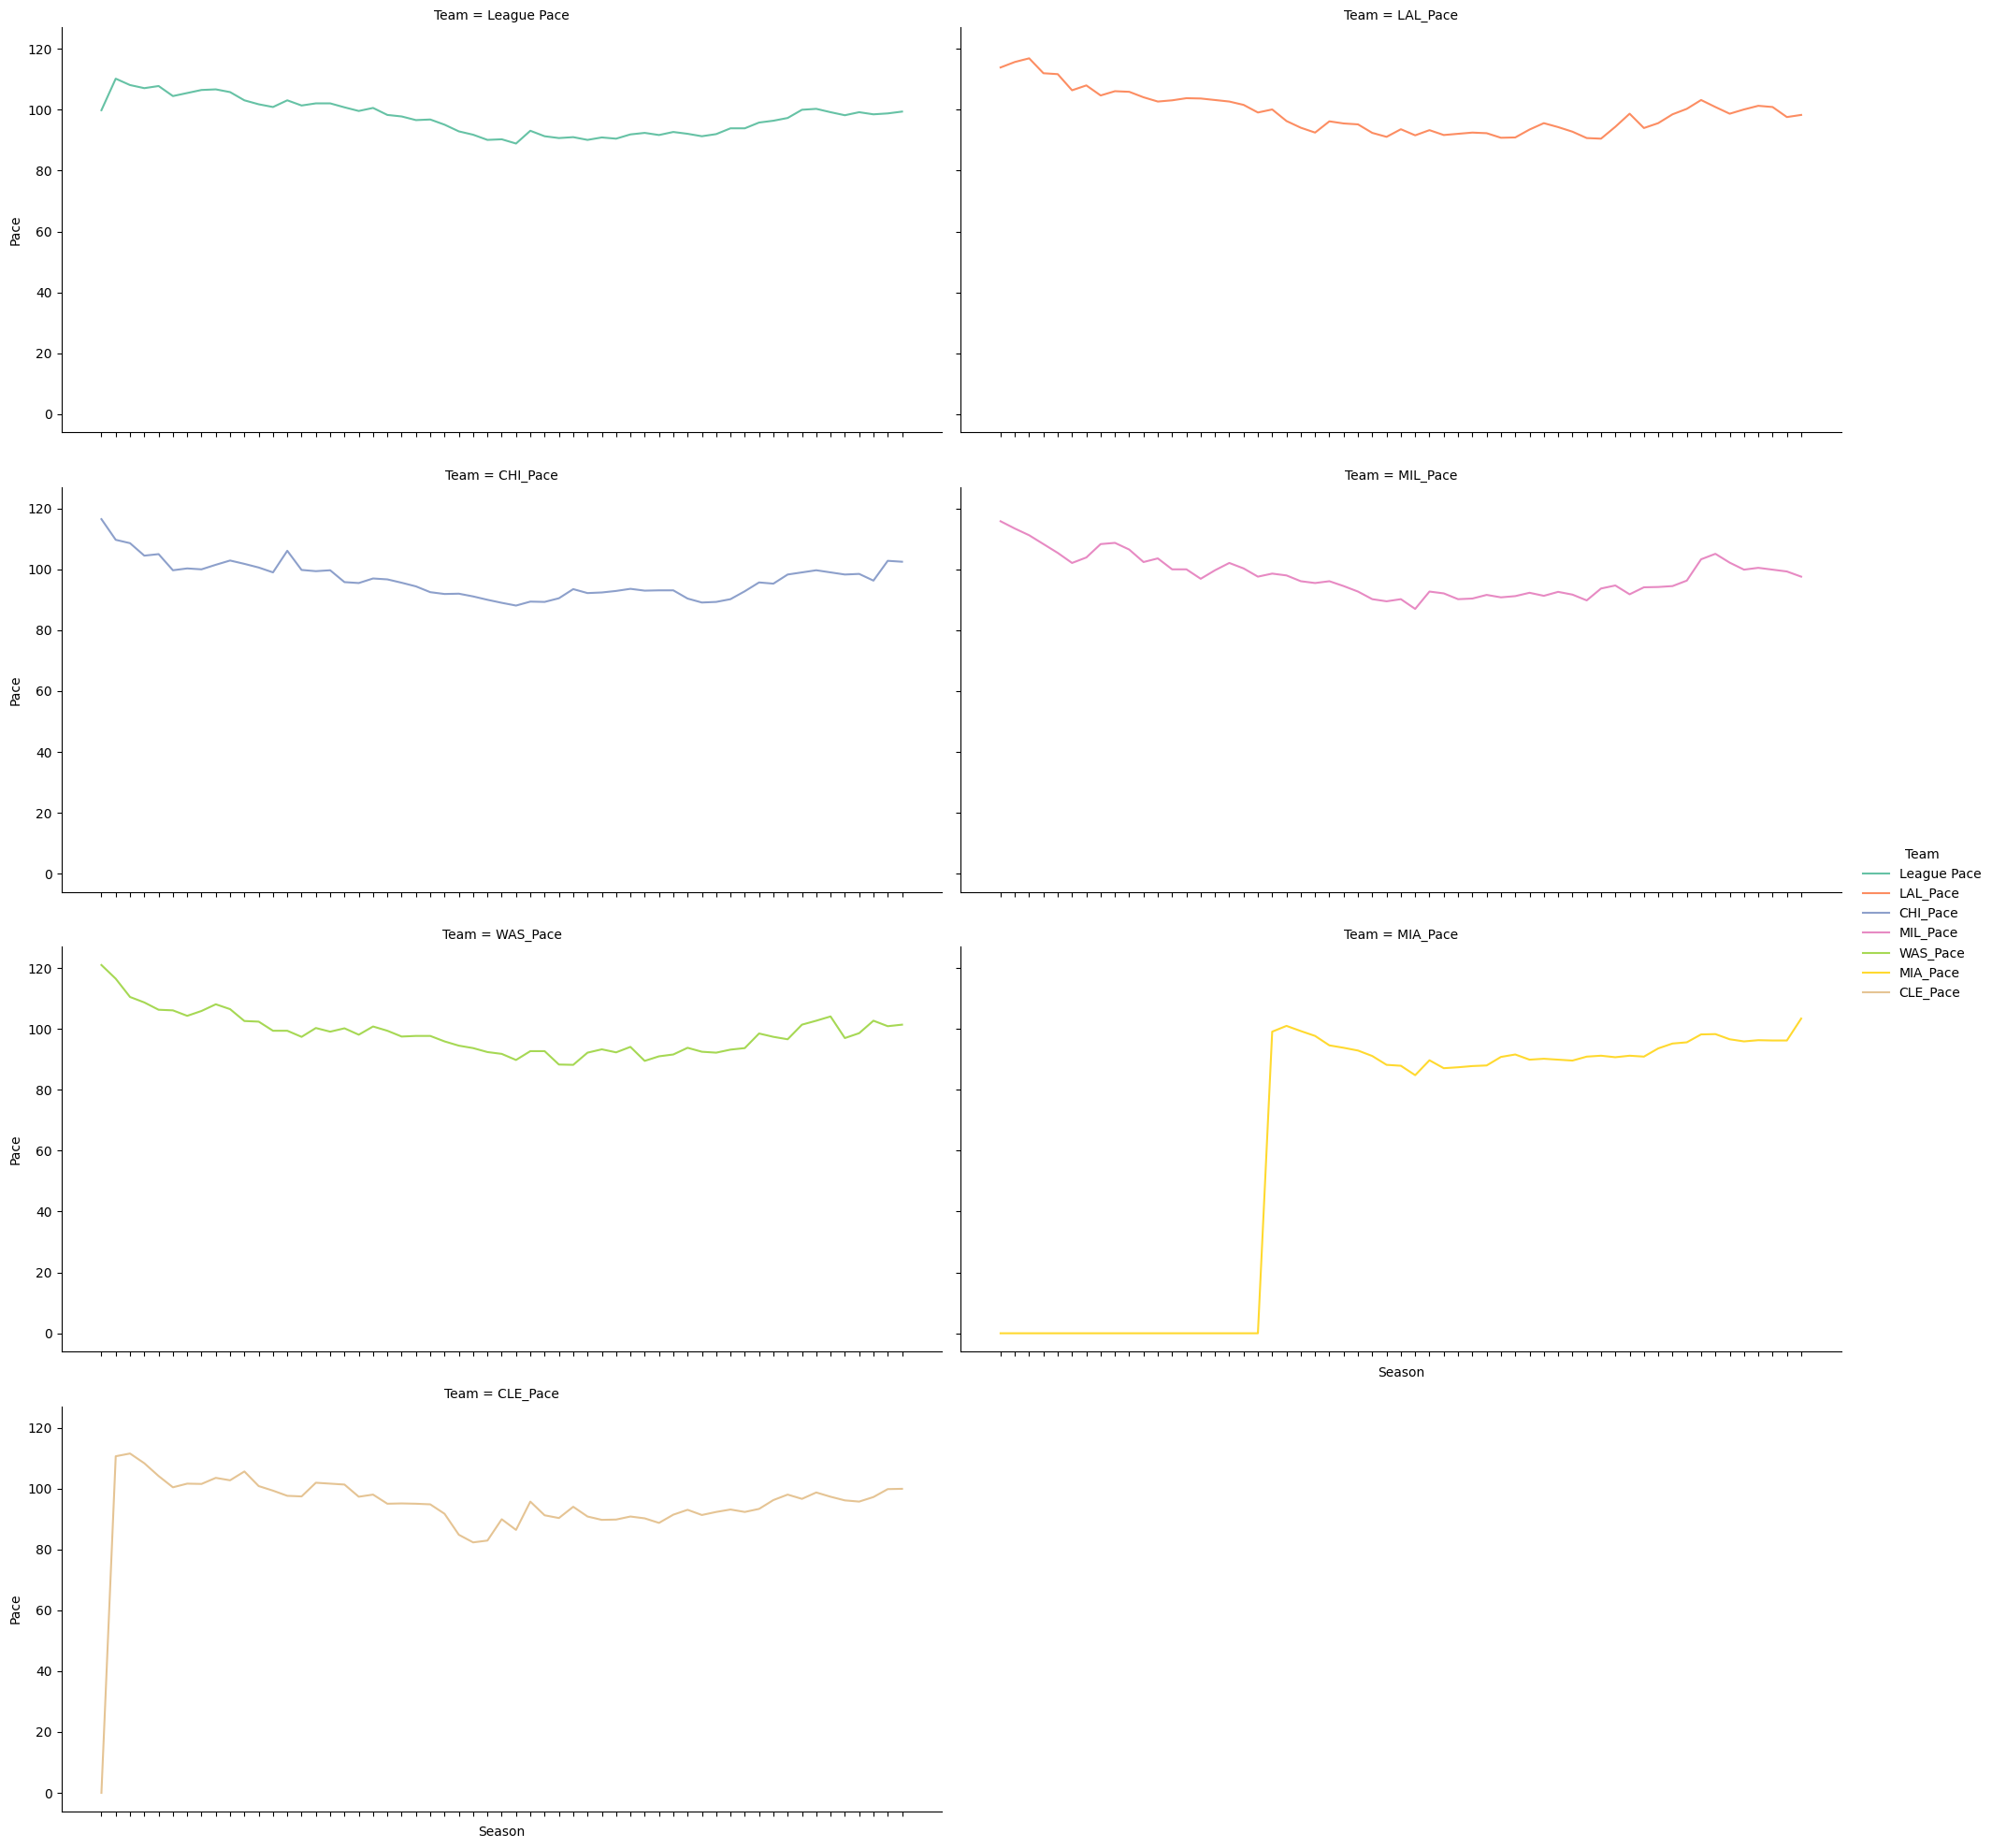

In [102]:
#Let us quickly visualize the pace of the league and teams over the years.

#We will create a facet grid to plot the pace of the league and teams over the years, this will allow us to visualize the pace, and produce a not so messy plot. 
#For each of the plots, we will start at the season where the team was active, as this is the only time we have pace data for each team. 

melted_pace = Pace.melt(id_vars = "Season", var_name = "Team", value_name = "Pace") #get the dataframe in the right format for facet grid.

Grid = sns.FacetGrid(melted_pace, 
              col = "Team",
              col_wrap = 2,
              height = 5,
              hue = "Team",
              sharey = True,
              sharex = True,
              aspect = 2,
              palette = "Set2"
              )

Grid.map(sns.lineplot, "Season", "Pace")
Grid.add_legend()
Grid.set_xticklabels(rotation = 90)

From the facet plot above it is quite evident that the pace of the game decreased very much around the 1990s-2000s era, going as low as around 90 at one point. This tells us that the nba was playing at a much slower rate making it obvious that the defensive force was at an all time high.  

In [103]:
#Now using the PER formula as defined above, we will calculate the PER for each player in each season, and add it as a new column to their respective dataframes.

def factor(lg_AST, lg_FT, lg_FG):
    return 2/3 - (lg_AST*lg_FT/lg_FG**2)/4

def VOP(lg_PTS, lg_FGA, lg_FTA, lg_ORB, lg_TOV): #Value of possession for the league with respect to each major statistical category, a factor in the PER formula. 
    return lg_PTS/(lg_FGA - lg_ORB + lg_TOV + 0.44*lg_FTA)

def DRBP(lg_ORB, lg_DRB, lg_TRB): #Proportion of defensive rebounds for the league.
    return (lg_TRB - lg_ORB)/lg_DRB

#Define unadjusted PER formula as defined by John Hollinger, the creator of the PER statistic. We will use this formula to calculate the PER for each player in each season, and then we will adjust it for pace and league averages later on.

def unadj_PER(
    P, lgFT, lgPF, FT, tmAST, tmFG, FG, factor,
    AST, VOP, DRBP, ORB, BLK, FTA, minutes, lgFTA, TO, TRB, STL, FGA
):
    term1 = 3 * P
    term2 = -(2.5 * (lgFT / lgPF))
    term3 = 0.5 * FT * (2 - (tmAST / (3 * tmFG)))
    term4 = FG * (2 - (factor * tmAST / tmFG))
    term5 = (2 * AST) / 3
    term6 = VOP * (DRBP * (2 * ORB + BLK - 0.2464 * (FTA - FT) - (FGA - FG) - TRB))
    term7 = 0.44*(lgFTA*2.5/lgPF) - (TO + ORB) + STL + TRB - 0.1936*(FTA - FT)

    return (1 / minutes) * (term1 + term2 + term3 + term4 + term5 + term6 + term7)

def PER(
    unadj_PER, tmPace, lg_unadj_PER_mean, lgPace_mean
):
    # lgPER must be the mean of the *unadjusted* league PER (a scalar),
    # and lgPace must also be a scalar mean — NOT a Series.
    # Passing the adjusted NBA_avg["PER"] column here would double-adjust the values.
    return unadj_PER * (lgPace_mean / tmPace) * (15 / lg_unadj_PER_mean)

Now that we have finally defined all of the functions we'll be using to calculate the `Player Efficiency Rating` for each player, we could go ahead and do this.

Recall:

Lebron James played for the following teams:
- Cleveland Caveliers (2003-2010, 2015-2018)
- Miami Heat (2011-2014)
- Los Angeles Lakers (2019-2026(present))

Micheal Jordan played for the following teams:
- Chicago Bulls (1986-2001)
- Washington Wizards (2002-2003)

Kareem Abdul Jabbar played for the following teams:
- Milwaukee Bucks (1969-1975)
- Los Angeles Lakers (1976-1989)

(As shown in the dataframes as well)

In [105]:
#First we will need to calculate the PER for the league.

#I will first extract all of the series from the dataframes that we will need to use in calculating the PER; setting acronyms for all.
#Team stats are targeted to specific players, so we will not hardcode them.
#And all variables without a prefix refer to stats for individual players.

# Convert league averages to league totals (30 teams)
teams = 30

lg_AST = NBA_avg["AST"] * teams
lg_FT  = NBA_avg["FT"]  * teams
lg_FG  = NBA_avg["FG"]  * teams
lg_ORB = NBA_avg["ORB"] * teams
lg_DRB = NBA_avg["DRB"] * teams
lg_PTS = NBA_avg["PTS"] * teams
lg_FGA = NBA_avg["FGA"] * teams
lg_FTA = NBA_avg["FTA"] * teams
lg_PF  = NBA_avg["PF"]  * teams
lg_TOV = NBA_avg["TOV"] * teams
lg_TRB = NBA_avg["TRB"] * teams

lg_Pace = Pace["League Pace"]  # pace is already per-team, do NOT multiply



lg_factor = factor(lg_AST, lg_FT, lg_FG)
lg_VOP = VOP(lg_PTS, lg_FGA, lg_FTA, lg_ORB, lg_TOV)
lg_DRBP = DRBP(lg_ORB, lg_DRB, lg_TRB)

lg_unadj_PER = unadj_PER(
    P = NBA_avg["PTS"],
    lgFT = lg_FT,
    lgPF = lg_PF,
    FT = NBA_avg["FT"],
    tmAST = NBA_avg["AST"],
    tmFG = NBA_avg["FG"],
    FG = NBA_avg["FG"],
    factor = lg_factor,
    AST = NBA_avg["AST"],
    VOP = lg_VOP,
    DRBP = lg_DRBP,
    ORB = NBA_avg["ORB"],
    BLK = NBA_avg["BLK"],
    FTA = NBA_avg["FTA"],
    minutes = NBA_avg["MP"],
    lgFTA = lg_FTA,
    TO = NBA_avg["TOV"],
    TRB = NBA_avg["TRB"],
    STL = NBA_avg["STL"],
    FGA = NBA_avg["FGA"]
)

NBA_avg["unadj_PER"] = lg_unadj_PER

lg_PER = PER(
    unadj_PER = lg_unadj_PER,
    tmPace = NBA_avg["Pace"],
    lg_unadj_PER_mean = lg_unadj_PER.mean(), 
    lgPace_mean = lg_Pace.mean()
)

NBA_avg["PER"] = lg_PER
NBA_avg[["Season","PER"]].head()

,Season,PER
0,2025-26,15.946441
1,2024-25,15.748930
2,2023-24,15.891065
3,2022-23,15.807609
4,2021-22,15.360818


In [106]:
#Now we will create PER columns for each player, for team assits and team field goals, 
#we will use average league assists and field goals, it wouldnt be ideal but since we do not have team stats in hand, this is the best estimate we have. 
#Lebron James

#Note: Below I have taken the sum of all nba average stats and multiplied them by 30, this is because in John Hollinger's original PER formula, the league totals are based on a 30 team league,
#and we are working with a 30 team league, where the NBA_avg dataset has averages per team, so we need to multiply by 30 to get the league totals.


LAL_LBJ = LAL[LAL["Season"] >= "2018-19"]
CLE_LBJ = CLE[(CLE["Season"].between("2003-04", "2009-10")) | (CLE["Season"].between("2014-15", "2017-18"))]
MIA_LBJ = MIA[MIA["Season"].between("2010-11", "2013-14")]

NBA_avg_LBJ = NBA_avg[NBA_avg["Season"] >= "2003-04"].reset_index() #We will only use league averages from the seasons that Lebron James played in.

LBJ_teams = pd.concat([LAL_LBJ, CLE_LBJ, MIA_LBJ], ignore_index = True).sort_values("Season").reset_index()

#compute era-specific unadjusted league PER mean and pace mean as scalars.
lg_unadj_PER_LBJ_mean = NBA_avg_LBJ["unadj_PER"].mean()   # scalar
lg_Pace_LBJ_mean      = NBA_avg_LBJ["Pace"].mean()         # scalar

LBJ_unadj_PER = unadj_PER(
    P       = LBJ["PTS"],
    lgFT    = NBA_avg_LBJ["FT"],
    lgPF    = NBA_avg_LBJ["PF"],
    FT      = LBJ["FT"],
    tmAST   = NBA_avg_LBJ["AST"],
    tmFG    = NBA_avg_LBJ["FG"],
    FG      = LBJ["FG"],
    factor  = factor(NBA_avg_LBJ["AST"], NBA_avg_LBJ["FT"], NBA_avg_LBJ["FG"]),
    AST     = LBJ["AST"],
    VOP     = VOP(NBA_avg_LBJ["PTS"], NBA_avg_LBJ["FGA"], NBA_avg_LBJ["FTA"], NBA_avg_LBJ["ORB"], NBA_avg_LBJ["TOV"]),
    DRBP    = DRBP(NBA_avg_LBJ["ORB"], NBA_avg_LBJ["DRB"], NBA_avg_LBJ["TRB"]),
    ORB     = LBJ["ORB"],
    BLK     = LBJ["BLK"],
    FTA     = LBJ["FTA"],
    minutes = LBJ["MP"],
    lgFTA   = NBA_avg_LBJ["FTA"],
    TO      = LBJ["TOV"],
    TRB     = LBJ["TRB"],
    STL     = LBJ["STL"],
    FGA     = LBJ["FGA"]
)

LBJ_PER = PER(
    unadj_PER         = LBJ_unadj_PER,
    tmPace            = LBJ_teams["Pace"],
    lg_unadj_PER_mean = lg_unadj_PER_LBJ_mean,  # scalar unadjusted mean 
    lgPace_mean       = lg_Pace_LBJ_mean         # scalar mean 
)


LBJ["PER"] = LBJ_PER
LBJ[["Season", "PER"]].head()

,Season,PER
0,2003-04,18.239786
1,2004-05,23.367480
2,2005-06,26.559870
3,2006-07,23.711713
4,2007-08,27.268012


In [107]:
#Kareem Abdul Jabbar


LAL_KAJ = LAL[LAL["Season"].between("1975-76", "1988-89")]
MIL_KAJ = MIL[MIL["Season"].between("1969-70", "1974-75")]

NBA_avg_KAJ = NBA_avg[NBA_avg["Season"].between("1969-70", "1988-89")].reset_index() #We will only use league averages from the seasons that Kareem Abdul Jabbar played in.


KAJ_teams = pd.concat([LAL_KAJ, MIL_KAJ], ignore_index = True).sort_values("Season").reset_index()

lg_unadj_PER_KAJ_mean = NBA_avg_KAJ["unadj_PER"].mean()   # scalar
lg_Pace_KAJ_mean      = NBA_avg_KAJ["Pace"].mean()         # scalar

KAJ_unadj_PER = unadj_PER(
    P       = KAJ["PTS"],
    lgFT    = NBA_avg_KAJ["FT"],
    lgPF    = NBA_avg_KAJ["PF"],
    FT      = KAJ["FT"],
    tmAST   = NBA_avg_KAJ["AST"],
    tmFG    = NBA_avg_KAJ["FG"],
    FG      = KAJ["FG"],
    factor  = factor(NBA_avg_KAJ["AST"], NBA_avg_KAJ["FT"], NBA_avg_KAJ["FG"]),
    AST     = KAJ["AST"],
    VOP     = VOP(NBA_avg_KAJ["PTS"], NBA_avg_KAJ["FGA"], NBA_avg_KAJ["FTA"], NBA_avg_KAJ["ORB"], NBA_avg_KAJ["TOV"]),
    DRBP    = DRBP(NBA_avg_KAJ["ORB"], NBA_avg_KAJ["DRB"], NBA_avg_KAJ["TRB"]),
    ORB     = KAJ["ORB"],
    BLK     = KAJ["BLK"],
    FTA     = KAJ["FTA"],
    minutes = KAJ["MP"],
    lgFTA   = NBA_avg_KAJ["FTA"],
    TO      = KAJ["TOV"],
    TRB     = KAJ["TRB"],
    STL     = KAJ["STL"],
    FGA     = KAJ["FGA"]
)

KAJ_PER = PER(
    unadj_PER         = KAJ_unadj_PER,
    tmPace            = KAJ_teams["Pace"],
    lg_unadj_PER_mean = lg_unadj_PER_KAJ_mean,  # scalar unadjusted mean — FIX
    lgPace_mean       = lg_Pace_KAJ_mean         # scalar mean — FIX
)


KAJ["PER"] = KAJ_PER
KAJ[["Season", "PER"]].head()

,Season,PER
0,1969-70,21.867527
1,1970-71,26.806557
2,1971-72,27.435274
3,1972-73,25.175710
4,1973-74,20.735592


In [108]:
#Micheal Jordan 


CHI_MJ = CHI[(CHI["Season"].between("1984-85", "1997-98")) & (CHI["Season"] != "1993-94")].sort_values("Season")
WAS_MJ = WAS[WAS["Season"].between("2001-02", "2002-03")]

MJ_teams = pd.concat([CHI_MJ, WAS_MJ], ignore_index = True)

NBA_avg_MJ = NBA_avg[NBA_avg["Season"].isin(MJ_teams["Season"])].sort_values("Season").reset_index() #We will only use league averages from the seasons that Michael Jordan played in.

lg_unadj_PER_MJ_mean = NBA_avg_MJ["unadj_PER"].mean()   # scalar
lg_Pace_MJ_mean      = NBA_avg_MJ["Pace"].mean()         # scalar

MJ_unadj_PER = unadj_PER(
    P       = MJ["PTS"],
    lgFT    = NBA_avg_MJ["FT"],
    lgPF    = NBA_avg_MJ["PF"],
    FT      = MJ["FT"],
    tmAST   = NBA_avg_MJ["AST"],
    tmFG    = NBA_avg_MJ["FG"],
    FG      = MJ["FG"],
    factor  = factor(NBA_avg_MJ["AST"], NBA_avg_MJ["FT"], NBA_avg_MJ["FG"]),
    AST     = MJ["AST"],
    VOP     = VOP(NBA_avg_MJ["PTS"], NBA_avg_MJ["FGA"], NBA_avg_MJ["FTA"], NBA_avg_MJ["ORB"], NBA_avg_MJ["TOV"]),
    DRBP    = DRBP(NBA_avg_MJ["ORB"], NBA_avg_MJ["DRB"], NBA_avg_MJ["TRB"]),
    ORB     = MJ["ORB"],
    BLK     = MJ["BLK"],
    FTA     = MJ["FTA"],
    minutes = MJ["MP"],
    lgFTA   = NBA_avg_MJ["FTA"],
    TO      = MJ["TOV"],
    TRB     = MJ["TRB"],
    STL     = MJ["STL"],
    FGA     = MJ["FGA"]
)

MJ_PER = PER(
    unadj_PER         = MJ_unadj_PER,
    tmPace            = MJ_teams["Pace"],
    lg_unadj_PER_mean = lg_unadj_PER_MJ_mean,  # scalar unadjusted mean — FIX
    lgPace_mean       = lg_Pace_MJ_mean         # scalar mean — FIX
)


MJ["PER"] = MJ_PER.round(2)
MJ[["Season", "PER"]].head()

,Season,PER
0,1984-85,25.19
1,1985-86,29.71
2,1986-87,32.27
3,1987-88,31.09
4,1988-89,28.68


In [ ]:
#Now I will compute relative PER for each player during the span of their careers, this will allow us to compare the players' PER relative to the league averages.
#This is statistically correct and efficient.

relative_PER_df = pd.DataFrame({
    "Season" : NBA_avg["Season"],
    "LBJ_relative_PER" : LBJ["PER"]/NBA_avg["PER"]
})

for season in relative_PER_df["Season"]:
    if season in KAJ["Season"].values:
        relative_PER_df.loc[relative_PER_df["Season"] == season, "KAJ_relative_PER"] = KAJ.loc[KAJ["Season"] == season, "PER"].values[0]/NBA_avg.loc[NBA_avg["Season"] == season, "PER"].values[0]
    else: 
        relative_PER_df.loc[relative_PER_df["Season"] == season, "KAJ_relative_PER"] = np.nan

    if season in MJ["Season"].values:
        relative_PER_df.loc[relative_PER_df["Season"] == season, "MJ_relative_PER"] = MJ.loc[MJ["Season"] == season, "PER"].values[0]/NBA_avg.loc[NBA_avg["Season"] == season, "PER"].values[0]
    else:
        relative_PER_df.loc[relative_PER_df["Season"] == season, "MJ_relative_PER"] = np.nan



(0     1984-85
 1     1985-86
 2     1986-87
 3     1987-88
 4     1988-89
 5     1989-90
 6     1990-91
 7     1991-92
 8     1992-93
 10    1994-95
 11    1995-96
 12    1996-97
 13    1997-98
 17    2001-02
 18    2002-03
 Name: Season, dtype: str,
 0     2025-26
 1     2024-25
 2     2023-24
 3     2022-23
 4     2021-22
 5     2020-21
 6     2019-20
 7     2018-19
 8     2017-18
 9     2016-17
 10    2015-16
 11    2014-15
 12    2013-14
 13    2012-13
 14    2011-12
 15    2010-11
 16    2009-10
 17    2008-09
 18    2007-08
 19    2006-07
 20    2005-06
 21    2004-05
 22    2003-04
 23    2002-03
 24    2001-02
 25    2000-01
 26    1999-00
 27    1998-99
 28    1997-98
 29    1996-97
 30    1995-96
 31    1994-95
 32    1993-94
 33    1992-93
 34    1991-92
 35    1990-91
 36    1989-90
 37    1988-89
 38    1987-88
 39    1986-87
 40    1985-86
 41    1984-85
 42    1983-84
 43    1982-83
 44    1981-82
 45    1980-81
 46    1979-80
 47    1978-79
 48    1977-78
 49    1976-7

In [109]:
#Now that we are done with cleaning and preprocessing out data, we will now round all statistics to 2 decimal places for better layout.

KAJ, LBJ, MJ, NBA_avg, LAL, CHI, MIL, WAS, MIA, CLE, Pace = [df.round(2) for df in [KAJ, LBJ, MJ, NBA_avg, LAL, CHI, MIL, WAS, MIA, CLE, Pace]]

C:\Users\Moahhid Amir\AppData\Local\Temp\ipykernel_14908\2018441619.py:3: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  KAJ, LBJ, MJ, NBA_avg, LAL, CHI, MIL, WAS, MIA, CLE, Pace = [df.round(2) for df in [KAJ, LBJ, MJ, NBA_avg, LAL, CHI, MIL, WAS, MIA, CLE, Pace]]


In [110]:
#Now that we have cleaned up our data, and created a PER column for each player to help us compare their careers, we will build a shiny app to visualize the careers of the three players.
#To do this we will first need to export the transfomed dataframes to a csv file, which we will then import into our shiny app, and use them to create our visualizations.

LBJ.to_csv("data/LBJ.csv", index = False)
MJ.to_csv("data/MJ.csv", index = False)
KAJ.to_csv("data/KAJ.csv", index = False)
NBA_avg.to_csv("data/NBA_avg.csv", index = False)
NBA_avg_standardized.to_csv("data/NBA_avg_standardized.csv", index = False)
Pace.to_csv("data/Pace.csv", index = False)

### Plots
----

Now I will be creating appropriate plots to see the differences and similarities in each players' careers.

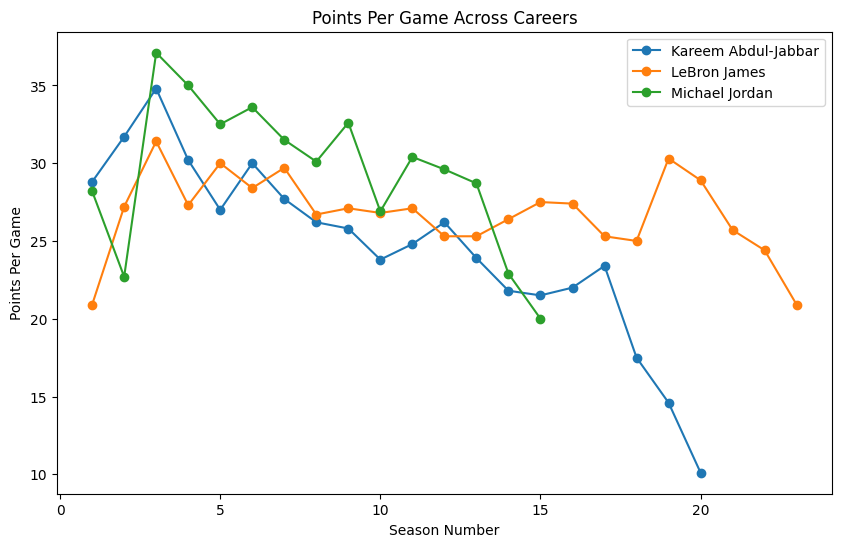

In [111]:
#Now we will create a line graph to compare the points per game of the three players across their careers.
plt.figure(figsize = (10, 6)) #This will create a figure with a specific size (or dimensions)

#Now we will plot the points per game for each player across their careers, this will remove any disproportionality in the x axis due to different in eras.
plt.plot("Season Number", "PTS", data = KAJ, label = "Kareem Abdul-Jabbar", marker = "o")
plt.plot("Season Number", "PTS", data = LBJ, label = "LeBron James", marker = "o")
plt.plot("Season Number", "PTS", data = MJ, label = "Michael Jordan", marker = "o")
plt.xlabel("Season Number") #This will set the label for the x axis to be "
plt.ylabel("Points Per Game")
plt.title("Points Per Game Across Careers")
plt.legend()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from shinywidget import ShinyWidget
from shiny import App, render, ui
from shiny import reactive, reactive_value, render_plot, render_table, render_text

LBJ = pd.read_csv(Path(__file__).parent / "data/LBJ.csv")
MJ = pd.read_csv(Path(__file__).parent / "data/MJ.csv")
KAJ = pd.read_csv(Path(__file__).parent / "data/KAJ.csv")
NBA_avg = pd.read_csv(Path(__file__).parent / "data/NBA_avg.csv")
Pace = pd.read_csv(Path(__file__).parent / "data/Pace.csv")
NBA_avg_standardized = pd.read_csv(Path(__file__).parent / "data/NBA_avg_standardized.csv")



### References


- Basketball Reference. (n.d.). Calculating PER. Basketball-Reference.com. [Basketball reference](https://www.basketball-reference.com/about/per.html)
- Shiny for Python. (n.d.). Shiny for Python. [Shinyapps](https://shiny.posit.co/py/)
- Microsoft Copilot: Your AI companion. (n.d.). Microsoft Copilot: Your AI Companion. [Copilot](https://copilot.microsoft.com/) - Copilot was used in assistance with research, and organize paper layout.
- NBA & ABA single season leaders and records for player efficiency rating | Basketball-Reference.com. (n.d.). Basketball-Reference.com. [Basketball Reference](https://www.basketball-reference.com/leaders/per_season.html)
‌